# Chatbot With MCP Server

In [1]:
%pip install langchain-mcp-adapters mcp pywin32 -Uqqq

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

### MCP Server 연동
- `http` 원격지의 MCP Server를 web 방식 호출
- `stdio` MCP Client system에서 MCP Server구동하는 경우

In [3]:
# MultiServerMCPClient로 MCP서버 2개 연결 후 도구 목록 조회
from langchain_mcp_adapters.client import MultiServerMCPClient
CONTEXT7_API_KEY = os.getenv('CONTEXT7_API_KEY')
# MCP 서버설정 클라이언트
mcp_client = MultiServerMCPClient({
    # Langchain Docs MCP 서버
    "docs-langchain": {
        "url": "https://docs.langchain.com/mcp", # 엔드포인트
        "transport": 'http' # 전송 방식
    },
    # Context7 MCP 서버
    "context7": {
        "url": "https://mcp.context7.com/mcp",   # 엔드포인트
        "headers": { # 인증정보를 담은 헤더
            "CONTEXT7_API_KEY": CONTEXT7_API_KEY
        },
        "transport": 'http'
    }
})
# get_tools는 비동기 메서드이므로 await로 동작 처리
mcp_tools = await mcp_client.get_tools() # MCP 서버 Tool 목록 조회
mcp_tools

[StructuredTool(name='search_docs_by_lang_chain', description='Search across the Docs by LangChain knowledge base to find relevant information, code examples, API references, and guides. Use this tool when you need to answer questions about Docs by LangChain, find specific documentation, understand how features work, or locate implementation details. The search returns contextual content with titles and direct links to the documentation pages. If you need the full content of a specific page, use the query_docs_filesystem tool to `head` or `cat` the page path (append `.mdx` to the path returned from search — e.g. `head -200 /api-reference/create-customer.mdx`).', args_schema={'type': 'object', 'properties': {'query': {'type': 'string', 'description': 'Search query'}}, 'required': ['query'], 'additionalProperties': False}, metadata={'title': None, 'readOnlyHint': True, 'destructiveHint': False, 'idempotentHint': True, 'openWorldHint': False}, handle_tool_error=<function _handle_mcp_tool_

In [4]:
from typing import TypedDict, Annotated, List # 타입 힌트 도구
from langgraph.graph.message import add_messages # 메세지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages : Annotated[List, add_messages] # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool] + mcp_tools
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 파인딩

# State의 messages를 입력 받아, 응답 메세지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages']) # 누적된 메세지 리스트로 LLM 호출
    return {'messages' : [response]} # add_messages 규칙에 의해 기존 messages에 응답이 누적됨


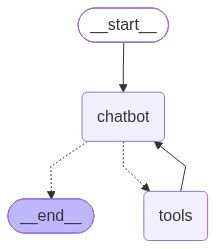

In [5]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State) # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot') # START -> chatbot

builder.add_node('chatbot', chatbot)     # chatbot
builder.add_node('tools', tool_node)     # tools

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile() # 설계된 builder를 실행 가능한 그래프로 컴파일
graph


In [ ]:
from pprint import pprint
user_query = '최근 삼성전자와 하이닉스 주가는 어떻게 돼?'
state = {'messages': [('human',user_query)]}

response = graph.invoke(state) # 그래프 비동기 실행
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='최근 삼성전자와 하이닉스 주가는 어떻게 돼?', additional_kwargs={}, response_metadata={}, id='fb51452e-3d31-4190-a4b8-a78f0130dd5f'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 3173, 'total_tokens': 3221, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrMkNwAzu0WdcvJp7FHwql34LHDS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06512-13a1-7273-b007-9898515836c4-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '삼성전자 하이닉스 주가 최근 현재 주가', 'search_depth'

In [10]:
user_query = 'langchain에서 새롭게 추가된 부분은? langchain MCP 사용해줘'
state = {'messages': [('human',user_query)]}

response = await graph.ainvoke(state) # 그래프 비동기 실행
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='langchain에서 새롭게 추가된 부분은? langchain MCP 사용해줘', additional_kwargs={}, response_metadata={}, id='641d2b47-600d-44d1-9b64-74d2d66415bd'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 3175, 'total_tokens': 3214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrPKG3l50bHIJvvOTyGKnqTOTUP8', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06514-83bf-7f82-8809-f19c65353bc3-0', tool_calls=[{'name': 'resolve-library-id', 'args': {'libraryName': 'LangChai

In [12]:
user_query = '웹 프레임워크 개발시 필요한 라이브러리가 뭐야? MCP 사용해'
state = {'messages': [('human',user_query)]}

response = await graph.ainvoke(state) # 그래프 비동기 실행
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='웹 프레임워크 개발시 필요한 라이브러리가 뭐야? MCP 사용해', additional_kwargs={}, response_metadata={}, id='e435b51a-452e-442b-8d2c-32c3f1c10b3a'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 3177, 'total_tokens': 3216, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrTG8gj7sWTsqVJAxIMF5MKnxk9t', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06518-3a6d-7171-8aa8-733989fc699f-0', tool_calls=[{'name': 'resolve-library-id', 'args': {'libraryName': 'MCP', 'query': 'L

In [13]:
from pprint import pprint
user_query = '여름 - 가을로 가는 중간지점에 먹을만한 음식은?'
state = {'messages': [('human',user_query)]}

response = graph.invoke(state) # 그래프 비동기 실행
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='여름 - 가을로 가는 중간지점에 먹을만한 음식은?', additional_kwargs={}, response_metadata={}, id='47e4cbc1-1226-40ae-8c0c-a7a8ea6d2da8'),
              AIMessage(content='여름에서 가을로 넘어가는 시기엔 **덜 무겁고, 너무 차갑지도 않고, 제철감 있는 음식**이 잘 어울려요. 추천하면:\n\n- **가지/호박/버섯 요리**: 살짝 구워서 먹는 구이, 볶음, 덮밥\n- **전복죽, 닭죽, 야채죽**: 여름 끝의 기운 떨어짐을 보완하면서 부담이 적음\n- **국수류**: 냉국수보다 **비빔국수, 잔치국수, 온국수**처럼 온도감이 조금 있는 것\n- **샐러드 + 구운 단백질**: 닭가슴살, 연어, 두부처럼 가볍게\n- **전/부침개**: 부추전, 애호박전, 버섯전\n- **구이 생선**: 고등어, 꽁치 같은 제철 생선\n- **가을 과일과 곁들인 간단식**: 배, 사과, 포도\n- **따뜻한 탕/찌개**: 너무 진하지 않은 된장국, 순두부찌개, 맑은 탕\n\n한 줄로 고르면:\n**버섯전 + 잔치국수**, **애호박볶음 + 구운 생선**, **닭죽**, **온국수** 같은 메뉴가 제일 무난해요.\n\n원하시면 제가  \n1) **한식 위주**, 2) **다이어트용**, 3) **편의점/간단식**, 4) **술안주용**  \n중 하나로 딱 맞게 추천해드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 386, 'prompt_tokens': 3179, 'total_tokens': 3565, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'r